# 4-2 : ピーク検出、全20天体解析
## プロット出力+結果一覧表作成

### --- TO DO ---

- 検出ピーク率にCIを付加する
- ピークの優位度：別スクリプトを作る必要がある
  - ピーク領域の同定(3点とは限らない)
  - 複数ピークの可能性
- 天体クラス表記大文字に統一

# Analyze and make a table


天体一覧の上位20天体
各天体について、
SED ecsvファイルの解析をする




## Utility
### - 天体名対応辞書作成

In [7]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  

  # sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars_converted  = sources_blazars.strip().replace('4FGL ','').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_selected_cls = sources_blazars_cls[idx]
  # print(sources_blazars_selected_cls)
  # print(sources_blazars_cls[idx])
  # The elements of sources_blazars_selected_cls are mixture of upper/lower cases. 
  # We unify them to upper case here.
  sources_blazars_selected_cls_converted = np.array([entry.upper() for entry in sources_blazars_selected_cls])
  # print(sources_blazars_selected_cls_converted)  

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_selected_cls_converted, #sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


### 使い方

In [8]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:2]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3c_454.3,FSRQ,1
j1104.4+3812,mkn_421,BLL,2


In [9]:
dict_sourcename[0]['assoc name']  = '3C454.3' 
dict_sourcename[1]['assoc name']  = 'Mrk421' 
dict_sourcename[2]['assoc name']  = 'BLLac' 
dict_sourcename[3]['assoc name']  = 'CTA102' 
dict_sourcename[4]['assoc name']  = '3C279'
dict_sourcename[5]['assoc name']  = 'S50716+71' 
dict_sourcename[6]['assoc name']  = 'PKS1424-41' 
dict_sourcename[7]['assoc name']  = 'PKS0426-380'
dict_sourcename[8]['assoc name']  = 'PKS0537-441'
dict_sourcename[9]['assoc name']  = 'PKS2155-304'
dict_sourcename[10]['assoc name'] = 'PKS0454-234'
dict_sourcename[11]['assoc name'] = 'PKS1510-089'
dict_sourcename[12]['assoc name'] = 'PKS1502+106'
dict_sourcename[13]['assoc name'] = 'TON599'
dict_sourcename[14]['assoc name'] = 'PKS0346-27'
dict_sourcename[15]['assoc name'] = '4c+01.02'
dict_sourcename[16]['assoc name'] = '4c+55.17'
dict_sourcename[17]['assoc name'] = '4c+21.35'
dict_sourcename[18]['assoc name'] = 'PKS1830-211'
dict_sourcename[19]['assoc name'] = 'PKS0208-512'
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3C454.3,FSRQ,1
j1104.4+3812,Mrk421,BLL,2
j2202.7+4216,BLLac,BLL,3
j2232.6+1143,CTA102,FSRQ,4
j1256.1-0547,3C279,FSRQ,5
j0721.9+7120,S50716+71,BLL,6
j1427.9-4206,PKS1424-41,FSRQ,7
j0428.6-3756,PKS0426-380,BLL,8
j0538.8-4405,PKS0537-441,BLL,9



## - Utility functions


### Probability table generation

14 bins from 9 to 22


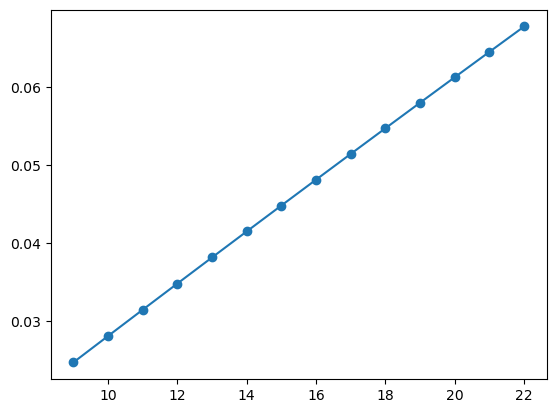

In [10]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

### Peak detection
### Gaussian
### Red.Chisq. calculation
### plotSED

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit
from scipy.stats import chi2, norm

###################
# Peak detection
###################
nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

###################
# Utility functions
###################
def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

################################################
### # Peak significance calculation - not used
### This must be used with the listing of all the data points
### of consecutive positive deviations, 
### which can be more than three
################################################
# def calc_peak_significance(ri):
# #     '''
# #     fit (array) values for the fit
# #     x,y,yerr (arrays) data
# #     N total number of points
# #     n_free number of parameters we are fitting
# #     '''
# #     return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)
# # import numpy as np
# # from scipy.stats import chi2, norm
# # # only those residuals that form the (at least) 3 consecutive positive deviations
# # ri = np.array([1, 2, 3.])

# # # Chi-square of those residuals
#   chi2_value = np.sum(ri**2)

# # # p-value for chi-square with m degrees of freedom - m = len(ri) - this is the probability of obtaining a test statistic at least as high as chi2_value
#   p_val = 1 - chi2.cdf(chi2_value, df=len(ri))

# # # p-value to Gaussian-equivalent one-sided significance
#   sigma_equiv = norm.ppf(1 - p_val)

#   return p_val, sigma_equiv



################################################
### # Confidence interval calculation - not used yet
### 
### 
### 
#################################################
# from scipy.stats import beta
# import numpy as np
# def calc_ci_ClopperPearson(k=20, n=400, alpha=0.32):
#   # k = 20
#   # n = 400
#   # alpha = 0.05
#   p_u, p_o = beta.ppf([alpha / 2, 1 - alpha / 2], [k, k + 1], [n - k + 1, n - k])
#   if np.isnan(p_o):
#       p_o = 1
#   if np.isnan(p_u):
#       p_u = 0
#   return p_u, p_o

def plotSED(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx, sourcename="",sourcenameheader=""):
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, fitted_line(x), '-', label='Fitted Line')
  plt.plot(x[peakbininit:peakbininit+nconsecutive],
           y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [MeV]')
  plt.ylabel(r"E$^2d\phi/d$E [MeV/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [MeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}.png", dpi=300, bbox_inches='tight')

def plotSED_erg_GeV(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx, sourcename='',sourcenameheader=''):
  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y = fitted_line(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', label='Fitted Line')
  plt.plot(x[peakbininit:peakbininit+nconsecutive],
           y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}.png", dpi=300, bbox_inches='tight')

###################
# Main function
###################
def eval_spectra(filepath,suffix='',sourcename=''): #'data/3C454.3_allsed_14d_min11.ecsv'

  sourcenameheader = ''
  if suffix != '':
    sourcenameheader = suffix + '_'

  if sourcename == '':
    sourcename = filepath.split('_')[0]
    sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta=0)
    # beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  array_chisq = []
  array_peakstat = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)
    
    ### fit the data with the fitter ###
    # logpar_init.amplitude.value=x[1]*1.0e-8
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr
    # print(fit.fit_info)
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    array_chisq.append(reduced_chi_squared)

    peakbininit = get_consecutive_bins(residuals,nconsecutive)

    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])
    if peakbininit > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += 1
      # array_peakstat.append(calc_peak_significance(residuals[peakbininit:peakbininit+nconsecutive]))
      plotSED_erg_GeV(x, y , yerr, fitted_line, peakbininit, nconsecutive, residuals, reduced_chi_squared, obsdate, idx, sourcename, sourcenameheader)


  ### bin数分布 ###
  fig = plt.figure(figsize=(8, 5))
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_nbins.png", dpi=300, bbox_inches='tight')

  ### 各Eの residual 分布 ###
  fig = plt.figure(figsize=(8, 5))
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_residuals.png", dpi=300, bbox_inches='tight')

  
  ### residual 分布 ###
  fig = plt.figure(figsize=(8, 5))
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  ymin, ymax = plt.ylim()
  plt.ylim(0.8,ymax)
  print('-- Gauss fit to residual distribution --')
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_residuals_hist.png", dpi=300, bbox_inches='tight')

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()
  print('-- Summary --')
  print('Source name:', sourcename)
  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))
  return sourcename, n_detected_peaks, len(array_nbins), len(obsdates), np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins)

In [ ]:
# dict_sourcename = get_dict_sourcenames()
n_brightest_sources = 20

array_data=[]

for sourceinfo in dict_sourcename[0:n_brightest_sources]:
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_14d_min11.ecsv'
  sourcename, n_detected_peaks, n_used_seds, n_used_seds_orig, prob_peaked_sed = eval_spectra(filepath, suffix=str(sourceinfo['index']), sourcename=sourceinfo['assoc name']) 
  ratio = n_detected_peaks / n_used_seds_orig
  array_data.append((sourceinfo['assoc name'], sourceinfo['4FGL name'].upper(), sourceinfo['CLASS'].upper(), n_detected_peaks, n_used_seds_orig, ratio, prob_peaked_sed))

headers = ['4FGL name', 'assoc name', 'CLASS', ' $N_p$', ' $N$ ','Ratio','Prediction']

textabular = f"l|{'r'*len(headers)}"
texheader = " & ".join(headers) + "\\\\"
texdata = "\\hline\n"
for data in array_data:
    # print(data)
    # texdata += f"{data[0]} & {data[1]} & {data[2]} & {data[3]} & {data[4]} \\\\\n"
    texdata += f"{data[1]} & {data[0]} & {data[2]} & {data[3]} & {data[4]} & {data[5]:.3f} & {data[6]:.3f} \\\\\n"

print("\\begin{tabular}{"+textabular+"}")
print(texheader)
print(texdata,end="")
print("\\end{tabular}")





3C454.3


/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_63804/4001534308.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.-- Gauss fit to residual distribution --
amplitude 357.1236011136773
mu 0.13762937300122757
sigma 0.9905633616034677

-- Summary --
Source name: 3C454.3
Number of detected peaks: 2
Number of used SEDs: 284
Number of SEDs: 284
Weighted average of the probability from theory:  0.04104678580839598
Mrk421
nbins < nbinsmin: 6
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
-- Gauss fit to residual distribution --Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

amplitude 656.3688758516865
mu 0.11044422161341737
sigma 

/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_63804/4001534308.py:137: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(10, 6))


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
-- Gauss fit to residual distribution --
amplitude 436.30789958901204
mu 0.14937360389400473
sigma -0.9453036516512074
-- Summary --
Source name: BLLac
Number of detected peaks: 10
Number of used SEDs: 299
Number of SEDs: 299
Weighted average of the probability from theory:  0.04475574276635105
CTA102
-- Gauss fit to residual distribution --Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

amplitude 229.33711533041418
mu 0.15341886036158955
sigma 0.9557291677470378
-- Summary --
Source name: CTA102
Number of detected peaks: 5
Number of used SE

\begin{tabular}{l|rrrrrr}
4FGL name & associated name & N detected peaks & N used SEDs & Ratio & Prediction\\
\hline
J$2253.9+1609$ & 3C454.3 & 2 & 284 & 0.007 & 0.041 \\
J$1104.4+3812$ & Mrk421 & 5 & 392 & 0.013 & 0.045 \\
J$2202.7+4216$ & BLLac & 10 & 299 & 0.033 & 0.045 \\
J$2232.6+1143$ & CTA102 & 5 & 179 & 0.028 & 0.041 \\
J$1256.1-0547$ & 3C279 & 6 & 261 & 0.023 & 0.040 \\
J$0721.9+7120$ & S50716+71 & 4 & 285 & 0.014 & 0.041 \\
J$1427.9-4206$ & PKS1424-41 & 3 & 299 & 0.010 & 0.044 \\
J$0428.6-3756$ & PKS0426-380 & 3 & 189 & 0.016 & 0.039 \\
J$0538.8-4405$ & PKS0537-441 & 2 & 224 & 0.009 & 0.038 \\
J$2158.8-3013$ & PKS2155-304 & 3 & 166 & 0.018 & 0.034 \\
J$0457.0-2324$ & PKS0454-234 & 2 & 242 & 0.008 & 0.038 \\
J$1512.8-0906$ & PKS1510-089 & 2 & 214 & 0.009 & 0.039 \\
J$1504.4+1029$ & PKS1502+106 & 0 & 147 & 0.000 & 0.039 \\
J$1159.5+2914$ & TON599 & 2 & 186 & 0.011 & 0.042 \\
J$0348.6-2749$ & PKS0346-27 & 2 & 111 & 0.018 & 0.044 \\
J$0108.6+0134$ & 4c+01.02 & 1 & 158 & 0.006 & 0.038 \\
J$0957.6+5523$ & 4c+55.17 & 0 & 57 & 0.000 & 0.027 \\
J$1224.9+2122$ & 4c+21.35 & 0 & 103 & 0.000 & 0.039 \\
J$1833.6-2103$ & PKS1830-211 & 1 & 117 & 0.009 & 0.040 \\
J$0210.7-5101$ & PKS0208-512 & 1 & 94 & 0.011 & 0.038 \\
\end{tabular}


\begin{tabular}{l|rrrrrrr}
4FGL name & assoc name & CLASS &  $N_p$ &  $N$  & Ratio & Prediction\\
\hline
J$2253.9+1609$ & 3C454.3 & FSRQ & 2 & 284 & 0.007 & 0.041 \\
J$1104.4+3812$ & Mrk421 & BLL & 5 & 392 & 0.013 & 0.045 \\
J$2202.7+4216$ & BLLac & BLL & 10 & 299 & 0.033 & 0.045 \\
J$2232.6+1143$ & CTA102 & FSRQ & 5 & 179 & 0.028 & 0.041 \\
J$1256.1-0547$ & 3C279 & FSRQ & 6 & 254 & 0.024 & 0.041 \\
J$0721.9+7120$ & S50716+71 & BLL & 1 & 282 & 0.004 & 0.043 \\
J$1427.9-4206$ & PKS1424-41 & FSRQ & 6 & 299 & 0.020 & 0.045 \\
J$0428.6-3756$ & PKS0426-380 & BLL & 5 & 197 & 0.025 & 0.040 \\
J$0538.8-4405$ & PKS0537-441 & BLL & 3 & 212 & 0.014 & 0.040 \\
J$2158.8-3013$ & PKS2155-304 & BLL & 4 & 194 & 0.021 & 0.036 \\
J$0457.0-2324$ & PKS0454-234 & FSRQ & 2 & 216 & 0.009 & 0.039 \\
J$1512.8-0906$ & PKS1510-089 & FSRQ & 2 & 216 & 0.009 & 0.040 \\
J$1504.4+1029$ & PKS1502+106 & FSRQ & 1 & 137 & 0.007 & 0.041 \\
J$1159.5+2914$ & TON599 & FSRQ & 1 & 170 & 0.006 & 0.043 \\
J$0348.6-2749$ & PKS0346-27 & FSRQ & 2 & 108 & 0.019 & 0.045 \\
J$0108.6+0134$ & 4c+01.02 & FSRQ & 3 & 143 & 0.021 & 0.038 \\
J$0957.6+5523$ & 4c+55.17 & FSRQ & 0 & 77 & 0.000 & 0.029 \\
J$1224.9+2122$ & 4c+21.35 & FSRQ & 2 & 97 & 0.021 & 0.040 \\
J$1833.6-2103$ & PKS1830-211 & FSRQ & 2 & 119 & 0.017 & 0.041 \\
J$0210.7-5101$ & PKS0208-512 & FSRQ & 1 & 89 & 0.011 & 0.039 \\
\end{tabular}